# **FNN Clasdification:**

## Binary Classification

In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from keras.models import Sequential
from keras.layers import Dense

# load the dataset
tips = sns.load_dataset("tips")

# preprocess the data
# Encoding the categories
le = LabelEncoder()
for col in tips:
    if tips[col].dtype == 'object' or tips[col].dtype == 'category':
        tips[col] = le.fit_transform(tips[col])
    else:
        pass

# create a binary target variable for binary classification
median_bill = tips['total_bill'].median()
tips['high_bill'] = (tips['total_bill'] > median_bill).astype(int)

# split the data into traing and test data sets
X = tips.drop(['total_bill', 'high_bill'], axis=1)
y = tips['high_bill']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=42)



In [35]:
tips.describe()

,total_bill,tip,sex,smoker,day,time,size,high_bill
count,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000
mean,19.785943,2.998279,0.643443,0.381148,1.741803,0.278689,2.569672,0.500000
std,8.902412,1.383638,0.479967,0.486667,0.926815,0.449276,0.951100,0.501028
min,3.070000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,13.347500,2.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,17.795000,2.900000,1.000000,0.000000,2.000000,0.000000,2.000000,0.500000
75%,24.127500,3.562500,1.000000,1.000000,3.000000,1.000000,3.000000,1.000000
max,50.810000,10.000000,1.000000,1.000000,3.000000,1.000000,6.000000,1.000000


In [36]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size,high_bill
0,16.99,1.01,0,0,2,0,2,0
1,10.34,1.66,1,0,2,0,3,0
2,21.01,3.50,1,0,2,0,3,1
3,23.68,3.31,1,0,2,0,2,1
4,24.59,3.61,0,0,2,0,4,1


In [37]:
# scale the feature data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# built the neural network
model = tf.keras.models.Sequential([
    tf.keras.layers.InputLayer(input_shape=[X_train.shape[1]]),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')

])

# compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# train the model
model.fit(X_train, y_train, epochs=10, batch_size=32)

# Evaluate the model

loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy ! {accuracy * 100:.2f}%")

Epoch 1/10


c:\Users\Zone Tech\.conda\envs\tensorflow_env\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.4410 - loss: 0.7823
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4051 - loss: 0.7684
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4000 - loss: 0.7559
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4051 - loss: 0.7454
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4103 - loss: 0.7368
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4410 - loss: 0.7288
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4769 - loss: 0.7212
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4974 - loss: 0.7145
Epoch 9/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4974 - loss: 0.7081
Epoch 10/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4974 - loss: 0.7029
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.4694 - loss: 0.6996 
Test Accuracy ! 46.94%


## Multiclass Classification

In [38]:
import pandas as pd
import numpy as np
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from keras.models import Sequential
from keras.layers import Dense

# load the dataset
tips = sns.load_dataset("tips")

# preprocess the data
# Encoding the categories
le = LabelEncoder()
for col in tips:
    if tips[col].dtype == 'object' or tips[col].dtype == 'category':
        tips[col] = le.fit_transform(tips[col])
    else:
        pass

# create a binary target variable for binary classification
median_bill = tips['total_bill'].median()
tips['high_bill'] = (tips['total_bill'] > median_bill).astype(int)


In [39]:
tips1 = sns.load_dataset('tips')
tips1.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [40]:
tips1.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [41]:
import pandas as pd
import numpy as np
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from keras.models import Sequential
from keras.layers import Dense

# load the dataset
tips = sns.load_dataset("tips")

# preprocess the data
# Encoding the categories
le = LabelEncoder()
for col in tips:
    if tips[col].dtype == 'object' or tips[col].dtype == 'category':
        tips[col] = le.fit_transform(tips[col])
    else:
        pass

# create a binary target variable for binary classification
median_bill = tips['total_bill'].median()
tips['high_bill'] = (tips['total_bill'] > median_bill).astype(int)

# split the data into traing and test data sets
X = tips.drop(['total_bill', 'high_bill'], axis=1)
y = tips['high_bill']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=42)

# scale the feature data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# built the neural network
model = tf.keras.models.Sequential([
    tf.keras.layers.InputLayer(input_shape=[X_train.shape[1]]),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')

])

# compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# train the model
model.fit(X_train, y_train, epochs=10, batch_size=32)

# Evaluate the model

loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy ! {accuracy * 100:.2f}%")

c:\Users\Zone Tech\.conda\envs\tensorflow_env\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.4974 - loss: 0.7544
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4923 - loss: 0.7396
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4923 - loss: 0.7278
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4872 - loss: 0.7159
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4974 - loss: 0.7046
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4974 - loss: 0.6961
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5128 - loss: 0.6872
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5077 - loss: 0.6794 
Epoch 9/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5179 - loss: 0.6730 
Epoch 10/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5231 - loss: 0.6664
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5306 - loss: 0.6749 
Test Accuracy ! 53.06%


In [43]:
import pandas as pd
import numpy as np
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from keras.models import Sequential
from keras.layers import Dense

# load the dataset
tips = sns.load_dataset("tips")

# preprocess the data
# Encoding the categories
le = LabelEncoder()
for col in tips:
    if tips[col].dtype == 'object' or tips[col].dtype == 'category':
        tips[col] = le.fit_transform(tips[col])
    else:
        pass

# create a binary target variable for binary classification
median_bill = tips['total_bill'].median()
tips['high_bill'] = (tips['total_bill'] > median_bill).astype(int)

# split the data into traing and test data sets
X = tips.drop('day', axis=1)
y = tips['day']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=42)

# scale the feature data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# built the neural network
model = tf.keras.models.Sequential([
    tf.keras.layers.InputLayer(input_shape=[X_train.shape[1]]),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(y_train.unique().shape[0], activation='softmax')

])

# compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# train the model
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Evaluate the model

loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy ! {accuracy * 100:.2f}%")

Epoch 1/10


c:\Users\Zone Tech\.conda\envs\tensorflow_env\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 176ms/step - accuracy: 0.3141 - loss: 1.3400 - val_accuracy: 0.2564 - val_loss: 1.3513
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.3269 - loss: 1.3298 - val_accuracy: 0.3590 - val_loss: 1.3404
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.3846 - loss: 1.3198 - val_accuracy: 0.3590 - val_loss: 1.3302
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.4103 - loss: 1.3100 - val_accuracy: 0.4103 - val_loss: 1.3202
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4615 - loss: 1.3007 - val_accuracy: 0.4103 - val_loss: 1.3098
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.4808 - loss: 1.2908 - val_accuracy: 0.3846 - val_loss: 1.2989
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4872 - loss: 1.2796 - val_accuracy: 0.4615 - val_loss: 1.2870
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5000 - loss: 1.2674 - val_accuracy: 0.4615 - val_loss: 1.2746
Epoch 9/10

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - accuracy: 0.6410 - loss: 0.7877 - val_accuracy: 0.6410 - val_loss: 0.8544
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.6474 - loss: 0.7842 - val_accuracy: 0.6410 - val_loss: 0.8539
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.6410 - loss: 0.7808 - val_accuracy: 0.6667 - val_loss: 0.8535
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.6410 - loss: 0.7773 - val_accuracy: 0.6667 - val_loss: 0.8511
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.6410 - loss: 0.7745 - val_accuracy: 0.6410 - val_loss: 0.8494
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6474 - loss: 0.7711 - val_accuracy: 0.6667 - val_loss: 0.8484
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.6474 - loss: 0.7685 - val_accuracy: 0.6667 - val_loss: 0.8463
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6474 - loss: 0.7658 - val_accuracy: 0.6667 - val_loss: 0.8458

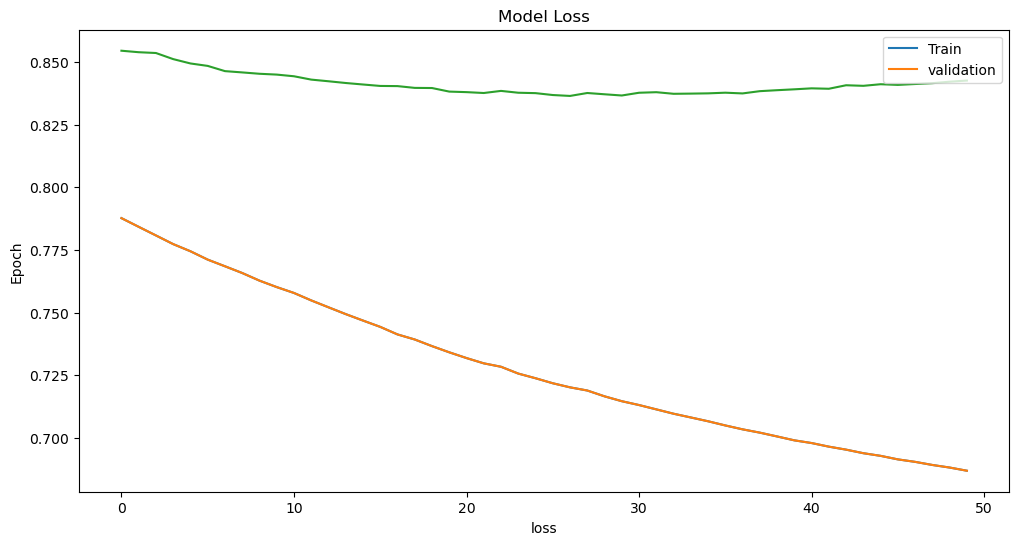

In [45]:
import matplotlib.pyplot as plt
# Train the model and store the history
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2)

# plot the traing and validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('loss')
plt.ylabel('Epoch')
plt.legend(['Train', 'validation'], loc='upper right')
plt.show()